In [ ]:
# ---
# jupyter:
#   jupytext:
#     formats: ipynb,py:percent
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.3
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---


# # LUNA16 bbox transform journey
#
# One case (`train_data[0]`) through the **bbox-changing** steps of the train pipeline (letters match `luna16_training.py`).
#
# **## headings** = MONAI transforms that move or reframe the box. Image-only steps are **###** subsections (box unchanged or stale until **S**).
#
# Each bbox stage:
# 1. **Matrix algebra** — Einstein form + 4×4 where relevant
# 2. **Q&A** — from the REPL walkthrough
# 3. **Code** — inline checks on `dA`…`dAF`
# 4. **Vector plots** — corner 0 as origin→point arrow before/after each affine map
# 5. **Box plots** — wireframe + ellipsoid nodule
#


In [ ]:
import matplotlib
matplotlib.use("Agg")  # before lidc_datalist → utilz (blocks qtagg)

import sys
from pathlib import Path

repo = Path("/home/ub/code/det3d")
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import matplotlib.pyplot as plt
plt.ioff()  # stop Jupyter auto plt.show() on Agg
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import monai
from monai.utils import set_determinism
from monai.transforms import (
    DeleteItemsd,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    Orientationd,
    RandAdjustContrastd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandGaussianNoised,
    RandGaussianSmoothd,
    RandRotate90d,
    RandRotated,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandZoomd,
    ScaleIntensityRanged,/
)
from monai.apps.detection.transforms.dictionary import (
    AffineBoxToImageCoordinated,
    BoxToMaskd,
    ClipBoxToImaged,
    ConvertBoxToStandardModed,
    MaskToBoxd,
    StandardizeEmptyBoxd,
)
from monai.transforms.spatial.dictionary import ConvertBoxToPointsd, ConvertPointsToBoxesd
from monai.transforms.utility.dictionary import ApplyTransformToPointsd
from det3d.detection.generate_transforms import GenerateExtendedBoxMask
from det3d.detection.lidc_datalist import load_lidc_train_val


project_title = "lidc"
plan_id = 1
ds_name = "lidc_all"
gt_box_mode = "cccwhd"
patch_size = [192, 192, 80]
batch_size = 4
intensity_clip_range = [-973.0, 429.0]
affine_lps_to_ras = False
amp = torch.cuda.is_available()
compute_dtype = torch.float16 if amp else torch.float32

image_key = "image"
box_key = "box"
label_key = "label"
point_key = "points"
NODULE = 0  # trace first nodule

train_data, val_data, meta = load_lidc_train_val(project_title, plan_id, ds_name)
print(meta["train_cases"], "train cases")

set_determinism(0)


In [ ]:
import io
from IPython.display import Image, display


def show_fig(fig):  #AI
    """Render Agg figure inline in Jupyter."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)


def _patched_show(*args, **kwargs):  #AI
    fig = plt.gcf()
    if fig.get_axes():
        show_fig(fig)


plt.show = _patched_show


def corners_from_box(box_row):
    b = box_row.detach().cpu().numpy() if torch.is_tensor(box_row) else np.asarray(box_row)
    x0, y0, z0, x1, y1, z1 = b
    return np.array([
        [x0, y0, z0], [x1, y0, z0], [x1, y1, z0], [x0, y1, z0],
        [x0, y0, z1], [x1, y0, z1], [x1, y1, z1], [x0, y1, z1],
    ])


def edges_from_corners(c):
    pairs = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7),
    ]
    return pairs


def box_center_radii(box_row):  #AI
    """Center and half-extents from xyzxyz box."""
    b = box_row.detach().cpu().numpy() if torch.is_tensor(box_row) else np.asarray(box_row)
    x0, y0, z0, x1, y1, z1 = b
    center = np.array([(x0 + x1) / 2, (y0 + y1) / 2, (z0 + z1) / 2])
    radii = np.array([(x1 - x0) / 2, (y1 - y0) / 2, (z1 - z0) / 2])
    return center, radii


def center_radii_from_corners(corners):  #AI
    c = np.asarray(corners)
    lo = c.min(axis=0)
    hi = c.max(axis=0)
    center = (lo + hi) / 2
    radii = (hi - lo) / 2
    return center, radii


def spheroid_surface(center, radii, n_u=24, n_v=16):  #AI
    u = np.linspace(0, 2 * np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)
    cu = np.cos(u)[:, None] * np.sin(v)[None, :]
    su = np.sin(u)[:, None] * np.sin(v)[None, :]
    sv = np.ones_like(cu) * np.cos(v)[None, :]
    cx, cy, cz = center
    rx, ry, rz = radii
    x = cx + rx * cu
    y = cy + ry * su
    z = cz + rz * sv
    return x, y, z


def draw_nodule_3d(ax, box_or_corners):  #AI
    """Wireframe box + solid ellipsoid nodule (xyzxyz box or 8 corners)."""
    arr = box_or_corners.detach().cpu().numpy() if torch.is_tensor(box_or_corners) else np.asarray(box_or_corners)
    if arr.shape == (6,):
        corners = corners_from_box(arr)
        center, radii = box_center_radii(arr)
    else:
        corners = arr
        center, radii = center_radii_from_corners(arr)
    for a, b in edges_from_corners(corners):
        xs = [corners[a, 0], corners[b, 0]]
        ys = [corners[a, 1], corners[b, 1]]
        zs = [corners[a, 2], corners[b, 2]]
        ax.plot(xs, ys, zs, "C0", lw=2)
    sx, sy, sz = spheroid_surface(center, radii)
    ax.plot_surface(sx, sy, sz, color="C1", alpha=0.55, linewidth=0, antialiased=True)
    ax.scatter(*center, c="k", s=15)


def plot_vector_tfm(stages, title=""):  #AI
    """Plot origin->point arrow in each coordinate frame (before/after an affine map)."""
    n = len(stages)
    fig = plt.figure(figsize=(4 * n, 4))
    for i, (label, pt, formula) in enumerate(stages):
        ax = fig.add_subplot(1, n, i + 1, projection="3d")
        p = np.asarray(pt, dtype=float)
        ax.quiver(0, 0, 0, p[0], p[1], p[2], color="C0", arrow_length_ratio=0.12, lw=2)
        ax.scatter(*p, c="C1", s=40)
        ax.scatter(0, 0, 0, c="k", s=20)
        ax.set_title(f"{label}\n{formula}", fontsize=8)
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        m = max(float(np.abs(p).max()), 1.0) * 1.25
        ax.set_xlim(-m, m); ax.set_ylim(-m, m); ax.set_zlim(-m, m)
    fig.suptitle(title)
    plt.tight_layout()
    show_fig(fig)


def plot_box_stages(stages, title=""):
    n = len(stages)
    fig = plt.figure(figsize=(4 * n, 4))
    for i, (label, box_or_corners) in enumerate(stages):
        ax = fig.add_subplot(1, n, i + 1, projection="3d")
        draw_nodule_3d(ax, box_or_corners)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    fig.suptitle(title)
    plt.tight_layout()
    show_fig(fig)


def affine_diag(d):
    A = d["image"].meta["affine"]
    t = A[:3, 3].tolist()
    s = A.diag()[:3].tolist()
    return s, t


intensity_transform = ScaleIntensityRanged(
    keys=[image_key],
    a_min=float(intensity_clip_range[0]),
    a_max=float(intensity_clip_range[1]),
    b_min=0.0,
    b_max=1.0,
    clip=True,
)

A = LoadImaged(keys=[image_key], image_only=False, meta_key_postfix="meta_dict")
B = EnsureChannelFirstd(keys=[image_key])
C = EnsureTyped(keys=[image_key, box_key], dtype=torch.float32)
D = EnsureTyped(keys=[label_key], dtype=torch.long)
E = StandardizeEmptyBoxd(box_keys=[box_key], box_ref_image_keys=image_key)
F = Orientationd(keys=[image_key], axcodes="RAS")
G = intensity_transform
H = EnsureTyped(keys=[image_key], dtype=torch.float16)
I = ConvertBoxToStandardModed(box_keys=[box_key], mode=gt_box_mode)
J = ConvertBoxToPointsd(keys=[box_key])
K = AffineBoxToImageCoordinated(
    box_keys=[box_key], box_ref_image_keys=image_key,
    image_meta_key_postfix="meta_dict", affine_lps_to_ras=affine_lps_to_ras,
)
L = GenerateExtendedBoxMask(keys=box_key, image_key=image_key, spatial_size=patch_size, whole_box=True)
M = RandCropByPosNegLabeld(
    keys=[image_key], label_key="mask_image", spatial_size=patch_size,
    num_samples=batch_size, pos=1, neg=1,
)
N = RandZoomd(keys=[image_key], prob=0.2, min_zoom=0.7, max_zoom=1.4, padding_mode="constant", keep_size=True)
O = RandFlipd(keys=[image_key], prob=0.5, spatial_axis=0)
P = RandFlipd(keys=[image_key], prob=0.5, spatial_axis=1)
Q = RandFlipd(keys=[image_key], prob=0.5, spatial_axis=2)
R = RandRotate90d(keys=[image_key], prob=0.75, max_k=3, spatial_axes=(0, 1))
S = ApplyTransformToPointsd(keys=[point_key], refer_keys=image_key, affine_lps_to_ras=affine_lps_to_ras)
T = ConvertPointsToBoxesd(keys=[point_key])
U = ClipBoxToImaged(box_keys=box_key, label_keys=[label_key], box_ref_image_keys=image_key, remove_empty=True)
V = BoxToMaskd(
    box_keys=[box_key], label_keys=[label_key], box_mask_keys=["box_mask"],
    box_ref_image_keys=image_key, min_fg_label=0, ellipse_mask=True,
)
W = RandRotated(
    keys=[image_key, "box_mask"], mode=["nearest", "nearest"], prob=0.2,
    range_x=np.pi / 6, range_y=np.pi / 6, range_z=np.pi / 6, keep_size=True, padding_mode="zeros",
)
X = MaskToBoxd(box_keys=[box_key], label_keys=[label_key], box_mask_keys=["box_mask"], min_fg_label=0)
Y = DeleteItemsd(keys=["box_mask"])
Z = RandGaussianNoised(keys=[image_key], prob=0.1, mean=0, std=0.1)
AA = RandGaussianSmoothd(keys=[image_key], prob=0.1, sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0), sigma_z=(0.5, 1.0))
AB = RandScaleIntensityd(keys=[image_key], prob=0.15, factors=0.25)
AC = RandShiftIntensityd(keys=[image_key], prob=0.15, offsets=0.1)
AD = RandAdjustContrastd(keys=[image_key], prob=0.3, gamma=(0.7, 1.5))
AE = EnsureTyped(keys=[image_key], dtype=compute_dtype)
AF = EnsureTyped(keys=[label_key], dtype=torch.long)


# ## Notation (used below)
#
# Homogeneous voxel index **v** = (i, j, k, 1)ᵀ and world point **x** = (x, y, z, 1)ᵀ (RAS mm).
#
# **Image affine** A in `image.meta["affine"]` (MONAI forward):
#
#     A @ v = x          (voxel index → world)
#
# Einstein form (a,b ∈ {0,1,2,3}):
#
#     x_a = A_ab v_b
#
# **Inverse** (world → voxel):
#
#     v = A⁻¹ @ x
#
# **Composition** after crop / zoom / flip / rotate90 — MONAI updates A for the **current** array:
#
#     A_new = T_spatial @ A_old
#
# **Crop** center c, patch size P, half = floor(P/2):
#
#     i_start = max(c_i - floor(P_i/2), 0)
#
# Patch voxel 0 maps to full-volume index i_start — folded into A at **M**.


# ## Raw datalist — world `cccwhd` box
#
# ### Matrix algebra
#
# Datalist box in **world mm**, mode `cccwhd`:
#
#     x_c, y_c, z_c, w, h, d   (center + sizes)
#
# No **A** yet — image is a path string, not a voxel array.
#
# ### Q&A
#
# **Q:** What is in the json before any transform?
#
# Box is **world** `cccwhd`. Image is a path only.
#


In [ ]:
d1 = dict(train_data[0])
d1["image"], d1["box"][NODULE], d1["label"]


# ### Preamble: A–F — load + orient (image only; box still world)
#
# ### Matrix algebra
#
# **F (Orientationd)** reorders voxel axes. Abstractly:
#
#     v_RAS = R_orient @ v_native
#
#     A_F = A_load @ R_orient⁻¹    (conceptually; MONAI writes the composed 4×4)
#
# Box in json stays world **x** — orientation-invariant:
#
#     x_a unchanged through F
#
# Only **image** voxels and **A** change. Alignment at **K** uses **A_F**, not the on-disk affine alone.
#
# ### Q&A
#
# **Q:** If **F** orients the image, doesn’t the box mis-align?
#
# **A:** Box stays **world** until **K**. **F** only reorders voxels + updates `image.meta["affine"]`. **K** applies **A⁻¹** to world corners.
#


In [ ]:
dA = A(d1)
dB = B(dA)
dC = C(dB)
dD = D(dC)
dE = E(dD)
dF = F(dE)
dF["image"].shape, dF["image"].meta.get("space"), dF["box"][NODULE]


# ## ConvertBoxToStandardModed (I) — `cccwhd` → `xyzxyz` world mm
#
# ### Matrix algebra
#
# **G–H** before **I** are intensity/dtype only (no spatial matrix):
#
#     I'(v) = clip((I(v) - a_min) / (a_max - a_min), 0, 1)
#
# **I** reparameterizes the same axis-aligned box in **world**:
#
#     cccwhd: (x_c, y_c, z_c, w, h, d)
#     xyzxyz: x_min = x_c - w/2,  x_max = x_c + w/2,  ...
#
# No 4×4 multiply — just six numbers for two opposite corners.
#
# ### Q&A
#
# **Q:** `xyzxyz` — is `[xmin, xmax]` a line?
#
# **A:** One 3D box: `[xmin, ymin, zmin, xmax, ymax, zmax]` — two opposite corners.
#


In [ ]:
dG = G(dF)
dH = H(dG)
dI = I(dH)
b = dI["box"][NODULE].tolist()
print("world xyzxyz", b)
print("x", b[0], b[3], "y", b[1], b[4], "z", b[2], b[5])


# ## ConvertBoxToPointsd (J) — box unchanged; add 8 world corner vectors
#
# ### Matrix algebra
#
# Expand axis-aligned world box to 8 corners **p**^(k) ∈ ℝ³, k = 1…8:
#
#     p^(1) = (x_min, y_min, z_min)
#     p^(8) = (x_max, y_max, z_max)
#     ... (all combinations of min/max per axis)
#
# Stack: **P** ∈ ℝ^(8×3). No multiply yet — **J** is bookkeeping:
#
#     points[n, k, :] = p_n^(k)
#
# ### Q&A
#
# **Q:** Each point is a 3D vector?
#
# **A:** Yes. Shape `(4, 8, 3)`. **J** adds `points`; **`box` unchanged** (still world).
#


In [ ]:
dJ = J(dI)
dJ["points"].shape, dJ["points"][NODULE, 0], dJ["box"][NODULE]


# ## AffineBoxToImageCoordinated (K) — `A⁻¹` on corners: world → full-volume voxel box
#
# ### Matrix algebra
#
# Let **A** = `dK["image"].meta["affine"]`. Forward (one voxel):
#
#     x = A @ v
#
# **K** maps each world corner **x** (homogeneous) to full-volume index **v**:
#
#     v = A⁻¹ @ x
#
# For box min/max corners, MONAI applies **A⁻¹** to both, then re-min/maxes axes.
#
# Example (diagonal A at dK, spacing s_i, translation t_i):
#
#     A = diag(s_x, s_y, s_z, 1) with last column (t_x, t_y, t_z, 1)
#
#     v_i = (x_i - t_i) / s_i
#
# **points** are not updated at **K** — only **box**.
#
# ### Q&A
#
# **Q:** Affine on vector — voxel → world?
#
# **A:** **`meta["affine"]`** maps **voxel → world**. **K** uses **`A⁻¹`** on box corners.
#


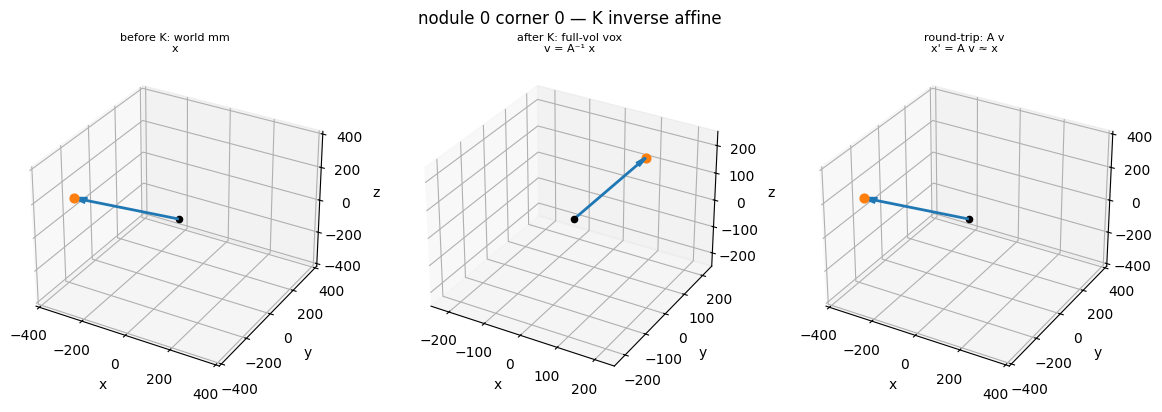

In [28]:
# explicit 4x4: v = A⁻¹ @ x  (corner 0)
dK = K(dJ)
A_k = dK["image"].meta["affine"]
p_w = dJ["points"][NODULE, 0]
x_h = torch.tensor([*p_w, 1.0], dtype=A_k.dtype)
v_h = torch.linalg.inv(A_k) @ x_h
print("A_k @ v ≈ x:", (A_k @ v_h)[:3].tolist(), "≈", p_w.tolist())
print("A_k diag/trans", affine_diag(dK))
print("box[0]", dK["box"][NODULE].tolist())
print("inv(A)@x", v_h[:3].tolist(), "  points still world", dK["points"][NODULE, 0].tolist())


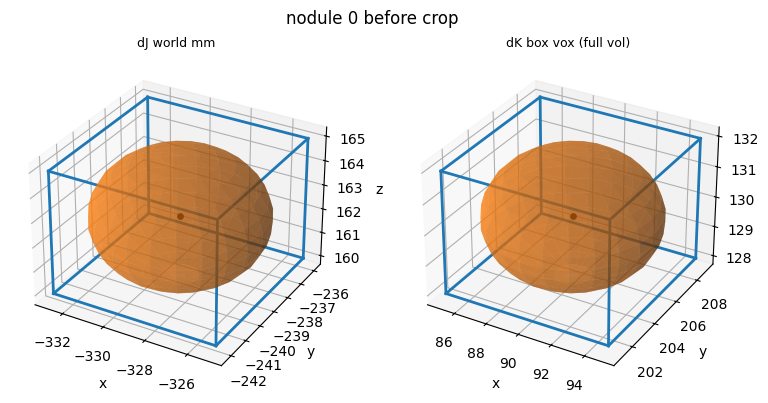

In [29]:
# K vector tfm: v = A⁻¹ @ x  (corner 0)
p_w = dJ["points"][NODULE, 0].cpu().numpy()
A_k = dK["image"].meta["affine"]
p_vox = (torch.linalg.inv(A_k) @ torch.tensor([*p_w, 1.0], dtype=A_k.dtype))[:3].cpu().numpy()
x_round = (A_k @ torch.tensor([*p_vox, 1.0], dtype=A_k.dtype))[:3].cpu().numpy()
plot_vector_tfm([
    ("before K: world mm", p_w, "x"),
    ("after K: full-vol vox", p_vox, "v = A⁻¹ x"),
    ("round-trip: A v", x_round, "x' = A v ≈ x"),
], title="nodule 0 corner 0 — K inverse affine")


In [ ]:
plot_box_stages([
    ("dJ world mm", dJ["points"][NODULE].cpu().numpy()),
    ("dK box vox (full vol)", corners_from_box(dK["box"][NODULE])),
], title="nodule 0 before crop")


# ### Between K and S: L — GenerateExtendedBoxMask (crop mask; box unchanged)
#
# ### Matrix algebra
#
# Per lesion, integer box bounds on axis $i$ with patch half $h_i = \lfloor P_i/2 \rfloor$, `whole_box=True`:
#
#     s_i = ceil(x_min,i)     e_i = floor(x_max,i)
#
#     ext_start_i = min(e_i - h_i - 1,  s_i)
#     ext_stop_i  = max(ext_start_i + h_i,  e_i)
#
# Valid crop-center indices on axis $i$ lie in $[\text{ext\_start}_i,\ \text{ext\_stop}_i]$ (heuristic, not exact MONAI crop set).
#
# Union over $N$ lesions for mask value at voxel **v**:
#
#     mask(v) = max_n  1[ ext_start_n ≤ v ≤ ext_stop_n ]
#
# (element-wise per axis). No change to lesion box **b**.
#
# ### Q&A
#
# **Q:** What is an extended box? Union of lesions?
#
# **A:** Per lesion inflated center-region; **`mask_image`** = OR over all. **`box` unchanged.**
#


In [ ]:
dL = L(dK)
image_size = dK["image"].shape[1:]
extended = L.generate_fg_center_boxes_np(dK["box"], image_size, whole_box=True)
print("lesion x", dK["box"][NODULE][:3].tolist(), dK["box"][NODULE][3:].tolist())
print("extended x", extended[NODULE][:3].tolist(), extended[NODULE][3:].tolist())
print("mask fg voxels", int((dL["mask_image"] > 0).sum()))


# ### Between K and S: M — RandCropByPosNegLabeld (patch image; box/points stale)
#
# ### Matrix algebra
#
# Pick crop center **c** (from mask). Patch indices **v'** ∈ [0, P) map to full-volume **v**:
#
#     v = v' + v_start,    v_start_i = max(c_i - floor(P_i/2), 0)
#
# MONAI updates affine so the **patch array** uses new origin:
#
#     A_M :  patch_vox  →  world
#     A_M = A_full @ T_translate(v_start)
#
# Only **image** cropped; **box** / **points** still in pre-crop frames until **S**.
#
# ### Q&A
#
# **Q:** Can RandCrop get half a lesion?
#
# **A:** **pos** from mask==1; **neg** from background. Only **`image`** cropped here.
#


In [ ]:
dM = M(dL)
pi = 0
print("patches", len(dM), "shape", dM[pi]["image"].shape)
print("crop_center", dM[pi]["image"].meta.get("crop_center"))
print("box still full-vol stale", dM[pi]["box"][NODULE].tolist())


# ### Between K and S: N–R — zoom / flip / rotate90 (patch image; `A` updates, points still world)
#
# ### Matrix algebra
#
# Each spatial op left-multiplies a 4×4 **T** into the stored affine:
#
#     A_R = T_R @ T_Q @ ... @ T_N @ A_M
#
# Examples (on patch indices, then folded into **A**):
#
# **Zoom** axis $i$ by $\gamma_i$:  $v''_i = \gamma_i v'_i$  → diagonal scale in **T_N**
#
# **Flip** axis $i$:  $v''_i = S_i v'_i$  with $S_i = \text{diag}(\ldots,-1,\ldots)$
#
# **Rotate90** in (i,j):  $v'' = R_{90}\, v'$  (permutation ± signs)
#
# **points** stay world **x** through N–R; only **A_R** catches up.
#
# ### Q&A
#
# **Q:** How do flips apply to box?
#
# **A:** Not yet — **S** applies **A_R⁻¹** to world corners in one shot.
#


In [ ]:
dN = N(dM[pi])
dO = O(dN)
dP = P(dO)
dQ = Q(dP)
dR = R(dQ)
print("dK affine", affine_diag(dK))
print("dR affine", affine_diag(dR))
print("points frozen world", dR["points"][NODULE, 0].tolist())


# ## ApplyTransformToPointsd (S) — `A⁻¹` on frozen world corners → patch voxel
#
# ### Matrix algebra
#
# Let **A** = `dR["image"].meta["affine"]` (patch vox → world). World corner **x** (from **J**, frozen):
#
#     v_patch = A⁻¹ @ x
#
# Einstein (one corner, spatial part):
#
#     v_i = (A⁻¹)_i{}^b x_b
#
# **One** matrix — not **A @ A⁻¹** on the same vector:
#
#     v_patch = A⁻¹ x_world     (different spaces in ↔ out)
#
# MONAI: `invert_affine=True` → use **A⁻¹** because stored **A** is forward vox→world and **points** are world.
#
# All 8 corners: same **A⁻¹** on each **x**^(k).
#
# ### Q&A
#
# **Q:** Affine then inv — identity?
#
# **A:** Single map world → patch voxel. **A** = `dR["image"].meta["affine"]`; **p_world** = `dR["points"][n,k]`.
#


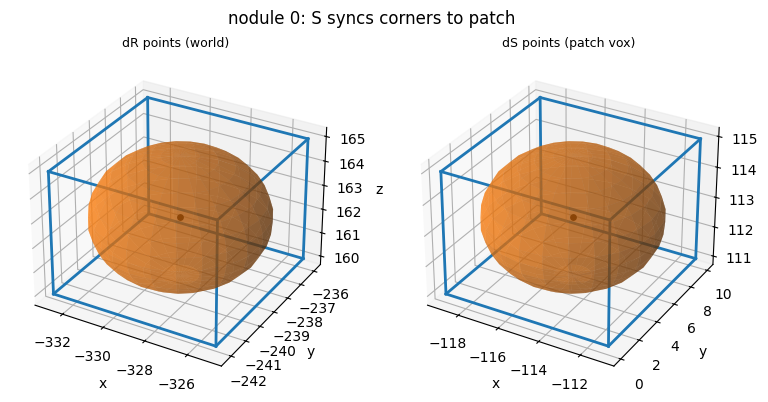

In [34]:
# v_patch = A_R⁻¹ @ x_world  (one matrix, not A @ A⁻¹ on same v)
p_world = dR["points"][NODULE, 0]
A_r = dR["image"].meta["affine"]
A_r_inv = torch.linalg.inv(A_r)
p_manual = (A_r_inv @ torch.tensor([*p_world, 1.0], dtype=A_r.dtype))[:3]
dS = S(dR)
p_after = dS["points"][NODULE, 0]
print("x_world", p_world.tolist())
print("A_r_inv @ x", p_manual.tolist())
print("S(points)", p_after.tolist())
print("round-trip A_r @ v", (A_r @ torch.tensor([*p_after, 1.0], dtype=A_r.dtype))[:3].tolist())
print("max |manual - S|", (p_manual - p_after).abs().max().item())


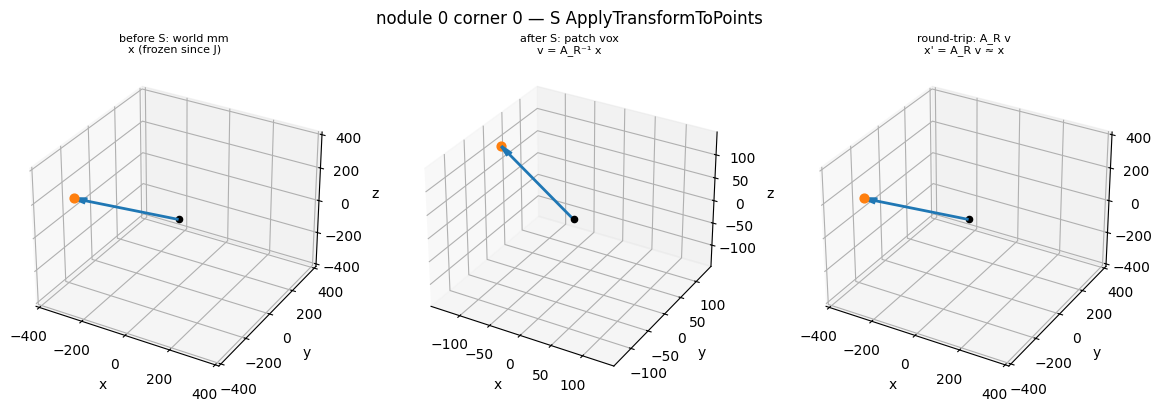

In [35]:
plot_box_stages([
    ("dR points (world)", dR["points"][NODULE].cpu().numpy()),
    ("dS points (patch vox)", dS["points"][NODULE].cpu().numpy()),
], title="nodule 0: S syncs corners to patch")


In [ ]:
# S vector tfm: v_patch = A_R⁻¹ @ x_world  (corner 0)
p_w = dR["points"][NODULE, 0].cpu().numpy()
p_patch = dS["points"][NODULE, 0].cpu().numpy()
A_r = dR["image"].meta["affine"]
x_round = (A_r @ torch.tensor([*p_patch, 1.0], dtype=A_r.dtype))[:3].cpu().numpy()
plot_vector_tfm([
    ("before S: world mm", p_w, "x (frozen since J)"),
    ("after S: patch vox", p_patch, "v = A_R⁻¹ x"),
    ("round-trip: A_R v", x_round, "x' = A_R v ≈ x"),
], title="nodule 0 corner 0 — S ApplyTransformToPoints")


# ## ConvertPointsToBoxesd (T) + ClipBoxToImaged (U) — hull + clip to patch grid
#
# ### Matrix algebra
#
# **T** — axis-aligned hull of 8 corners (no new matrix):
#
#     x_min = min_k p_k,x,   x_max = max_k p_k,x,   ...
#
# **U** — clip to patch grid [0, W)×[0, H)×[0, D):
#
#     x_min' = max(x_min, 0),   x_max' = min(x_max, W-1),   ...
#
# Drop box if empty after clip.
#
# ### Q&A
#
# Same patch-voxel frame as **S**; repack + clamp only.
#


In [ ]:
dT = T(dS)
dU = U(dT)
dT["box"][0], dU["box"].shape, dU["label"]


# ## BoxToMaskd (V) → RandRotated (W) → MaskToBoxd (X) — rotation round-trip
#
# ### Matrix algebra
#
# **V** rasterizes box to binary mask **M** on patch grid.
#
# **W** applies 3D rotation **R** (same on image and mask):
#
#     I'(v) = I(R⁻¹ v),    M'(v) = M(R⁻¹ v)
#
# (voxel/nearest sampling — not a simple 4×4 on 6 box numbers.)
#
# **X** — axis-aligned bounding box of rotated foreground voxels:
#
#     x_min = min{ v_i : M'(v)=1 },   ...
#
# Corner-only **A⁻¹** would fail for arbitrary **R**; mask round-trip fixes that.
#
# ### Q&A
#
# Arbitrary rotation → **box → mask → R → mask → box**.
#


In [ ]:
dV = V(dU)
dW = W(dV)
dX = X(dW)
dY = Y(dX)
print("box before W", dV["box"][0].tolist())
print("box after X", dX["box"][0].tolist())


# ### Tail: Z–AF — intensity + dtype (no bbox change)
#
# ### Matrix algebra
#
# Intensity ops are **per-voxel scalars**, not 4×4 spatial maps:
#
#     I'(v) = I(v) + noise,   I'(v) = I(v)^γ,   ...
#
# No change to **box** geometry after **X**. **AE/AF** cast dtype only.
#


In [ ]:
dZ = Z(dY)
dAA = AA(dZ)
dAB = AB(dAA)
dAC = AC(dAB)
dAD = AD(dAC)
dAE = AE(dAD)
dAF = AF(dAE)
dAF["image"].shape, dAF["image"].dtype, dAF["box"].shape


# ## Summary — corner 0 through every bbox transform
#
# Same corner 0 through the pipeline:
#


In [ ]:
p = dJ["points"][NODULE, 0]; print("J world", p.tolist())
p = dK["points"][NODULE, 0]; print("K world (unchanged)", p.tolist())
p = dR["points"][NODULE, 0]; print("R world (unchanged)", p.tolist())
p = dS["points"][NODULE, 0]; print("S patch vox", p.tolist())
p = dT["points"][NODULE, 0]; print("T same", p.tolist())
print("U box", dU["box"][0].tolist())
print("AF box", dAF["box"][0].tolist())


NameError: name 'plot_box_stages' is not defined

In [ ]:
plot_box_stages([
    ("dK full-vol vox", corners_from_box(dK["box"][NODULE])),
    ("dS patch vox", dS["points"][NODULE].cpu().numpy()),
    ("dAF final vox", corners_from_box(dAF["box"][0])),
], title="nodule 0 geometry milestones")


In [ ]:
# corner 0 vector journey across affine stages
p_w = dJ["points"][NODULE, 0].cpu().numpy()
p_k = (torch.linalg.inv(dK["image"].meta["affine"]) @ torch.tensor([*p_w, 1.0]))[:3].cpu().numpy()
p_s = dS["points"][NODULE, 0].cpu().numpy()
p_af = corners_from_box(dAF["box"][0])[0]
plot_vector_tfm([
    ("J world mm", p_w, "x"),
    ("K full-vol vox", p_k, "A_K⁻¹ x"),
    ("S patch vox", p_s, "A_R⁻¹ x"),
    ("AF patch vox", p_af, "after clip/rotate"),
], title="corner 0 vector journey (nodule 0)")